In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
daf=pd.read_csv("../data/raw/dataset_transacciones/hey_productos.csv")

In [3]:
daf.describe()

,limite_credito,saldo_actual,utilizacion_pct,tasa_interes_anual,plazo_meses,monto_mensualidad
count,14317.000000,35159.000000,14317.000000,18791.000000,4550.000000,4550.000000
mean,89630.928267,60007.057381,0.432751,29.116338,23.067692,1990.703200
std,94668.497000,84090.727992,0.250377,15.483885,13.751438,1683.125761
min,1000.000000,100.940000,0.050100,3.500000,6.000000,36.290000
25%,29000.000000,15596.240000,0.236100,14.655000,12.000000,738.237500
50%,64000.000000,36290.090000,0.370000,31.740000,18.000000,1477.315000
75%,111000.000000,66193.265000,0.576200,41.060000,24.000000,2784.105000
max,494000.000000,499905.570000,1.000000,66.970000,60.000000,11379.420000


In [4]:
daf.info()

<class 'pandas.DataFrame'>
RangeIndex: 38909 entries, 0 to 38908
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   producto_id              38909 non-null  str    
 1   user_id                  38909 non-null  str    
 2   tipo_producto            38909 non-null  str    
 3   fecha_apertura           38909 non-null  str    
 4   estatus                  38909 non-null  str    
 5   limite_credito           14317 non-null  float64
 6   saldo_actual             35159 non-null  float64
 7   utilizacion_pct          14317 non-null  float64
 8   tasa_interes_anual       18791 non-null  float64
 9   plazo_meses              4550 non-null   float64
 10  monto_mensualidad        4550 non-null   float64
 11  fecha_ultimo_movimiento  38909 non-null  str    
 12  es_dato_sintetico        38909 non-null  bool   
dtypes: bool(1), float64(6), str(6)
memory usage: 3.6 MB


In [5]:
daf.isnull().sum()

producto_id                    0
user_id                        0
tipo_producto                  0
fecha_apertura                 0
estatus                        0
limite_credito             24592
saldo_actual                3750
utilizacion_pct            24592
tasa_interes_anual         20118
plazo_meses                34359
monto_mensualidad          34359
fecha_ultimo_movimiento        0
es_dato_sintetico              0
dtype: int64

In [6]:
daf.isnull().sum().sort_values(ascending=False)

monto_mensualidad          34359
plazo_meses                34359
limite_credito             24592
utilizacion_pct            24592
tasa_interes_anual         20118
saldo_actual                3750
estatus                        0
tipo_producto                  0
user_id                        0
producto_id                    0
fecha_apertura                 0
fecha_ultimo_movimiento        0
es_dato_sintetico              0
dtype: int64

In [7]:
productos = daf.copy()

In [8]:
import pandas as pd
import numpy as np

productos_limpios = productos.copy()

# Convertir fechas
productos_limpios["fecha_apertura"] = pd.to_datetime(
    productos_limpios["fecha_apertura"], errors="coerce"
)

productos_limpios["fecha_ultimo_movimiento"] = pd.to_datetime(
    productos_limpios["fecha_ultimo_movimiento"], errors="coerce"
)

# Quitar espacios en columnas de texto
columnas_texto = productos_limpios.select_dtypes(include=["object"]).columns

for col in columnas_texto:
    productos_limpios[col] = productos_limpios[col].astype(str).str.strip()

# Reemplazar posibles "nan" convertidos a texto
productos_limpios = productos_limpios.replace("nan", np.nan)

# Crear indicadores antes de rellenar nulos
productos_limpios["tiene_limite_credito"] = productos_limpios["limite_credito"].notna().astype(int)
productos_limpios["tiene_utilizacion"] = productos_limpios["utilizacion_pct"].notna().astype(int)
productos_limpios["tiene_tasa_interes"] = productos_limpios["tasa_interes_anual"].notna().astype(int)
productos_limpios["tiene_plazo"] = productos_limpios["plazo_meses"].notna().astype(int)
productos_limpios["tiene_mensualidad"] = productos_limpios["monto_mensualidad"].notna().astype(int)
productos_limpios["tiene_saldo"] = productos_limpios["saldo_actual"].notna().astype(int)

# Columnas numéricas donde el nulo significa "no aplica"
columnas_no_aplica = [
    "limite_credito",
    "saldo_actual",
    "utilizacion_pct",
    "tasa_interes_anual",
    "plazo_meses",
    "monto_mensualidad"
]

productos_limpios[columnas_no_aplica] = productos_limpios[columnas_no_aplica].fillna(0)

# Rellenar textos faltantes, por seguridad
columnas_texto = productos_limpios.select_dtypes(include=["object"]).columns
productos_limpios[columnas_texto] = productos_limpios[columnas_texto].fillna("sin_dato")

# Si quedara alguna fecha nula, poner fecha controlada
productos_limpios["fecha_apertura"] = productos_limpios["fecha_apertura"].fillna(pd.Timestamp("1900-01-01"))
productos_limpios["fecha_ultimo_movimiento"] = productos_limpios["fecha_ultimo_movimiento"].fillna(pd.Timestamp("1900-01-01"))

# Validación
print("Nulos totales:", productos_limpios.isnull().sum().sum())
productos_limpios.isnull().sum().sort_values(ascending=False).head(20)

Nulos totales: 0


C:\Users\CommodorePlus\AppData\Local\Temp\ipykernel_21024\4264093228.py:16: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  columnas_texto = productos_limpios.select_dtypes(include=["object"]).columns
C:\Users\CommodorePlus\AppData\Local\Temp\ipykernel_21024\4264093228.py:45: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See ht

producto_id                0
user_id                    0
tipo_producto              0
fecha_apertura             0
estatus                    0
limite_credito             0
saldo_actual               0
utilizacion_pct            0
tasa_interes_anual         0
plazo_meses                0
monto_mensualidad          0
fecha_ultimo_movimiento    0
es_dato_sintetico          0
tiene_limite_credito       0
tiene_utilizacion          0
tiene_tasa_interes         0
tiene_plazo                0
tiene_mensualidad          0
tiene_saldo                0
dtype: int64

#Métricas

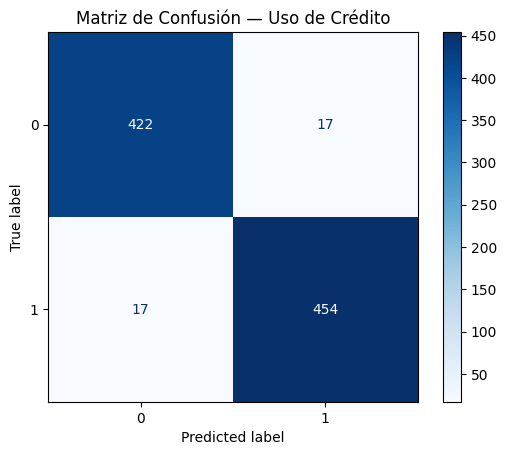

              precision    recall  f1-score   support

           0       0.96      0.96      0.96       439
           1       0.96      0.96      0.96       471

    accuracy                           0.96       910
   macro avg       0.96      0.96      0.96       910
weighted avg       0.96      0.96      0.96       910



In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

import numpy as np

# Crear target: uso alto vs bajo
daf['uso_alto'] = (daf['utilizacion_pct'] > daf['utilizacion_pct'].median()).astype(int)

# Variables predictoras
features = [
    'limite_credito',
    'saldo_actual',
    'tasa_interes_anual',
    'plazo_meses',
    'monto_mensualidad'
]

X = daf[features].dropna()
y = daf.loc[X.index, 'uso_alto']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Escalar
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Modelo
model = LogisticRegression()
model.fit(X_train, y_train)

# Predicción
y_pred = model.predict(X_test)

# Matriz
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot(cmap='Blues')

plt.title('Matriz de Confusión — Uso de Crédito')
plt.show()

print(classification_report(y_test, y_pred))

In [10]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

X_vif = daf[features].dropna()

vif = pd.DataFrame()
vif["Variable"] = X_vif.columns
vif["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(len(X_vif.columns))
]

print(vif)

             Variable        VIF
0      limite_credito   5.634825
1        saldo_actual  12.370136
2  tasa_interes_anual   6.228692
3         plazo_meses   7.747000
4   monto_mensualidad   9.479029


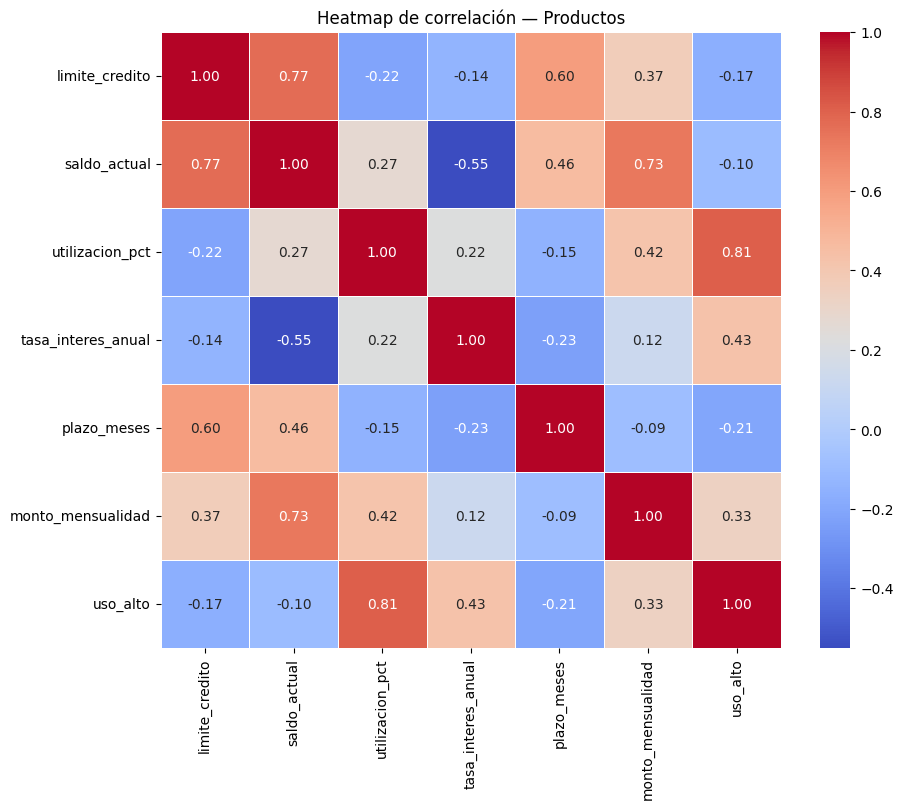

In [11]:
daf_num = daf.select_dtypes(include=['int64','float64'])

corr = daf_num.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Heatmap de correlación — Productos')
plt.show()

#Portafolio por producto

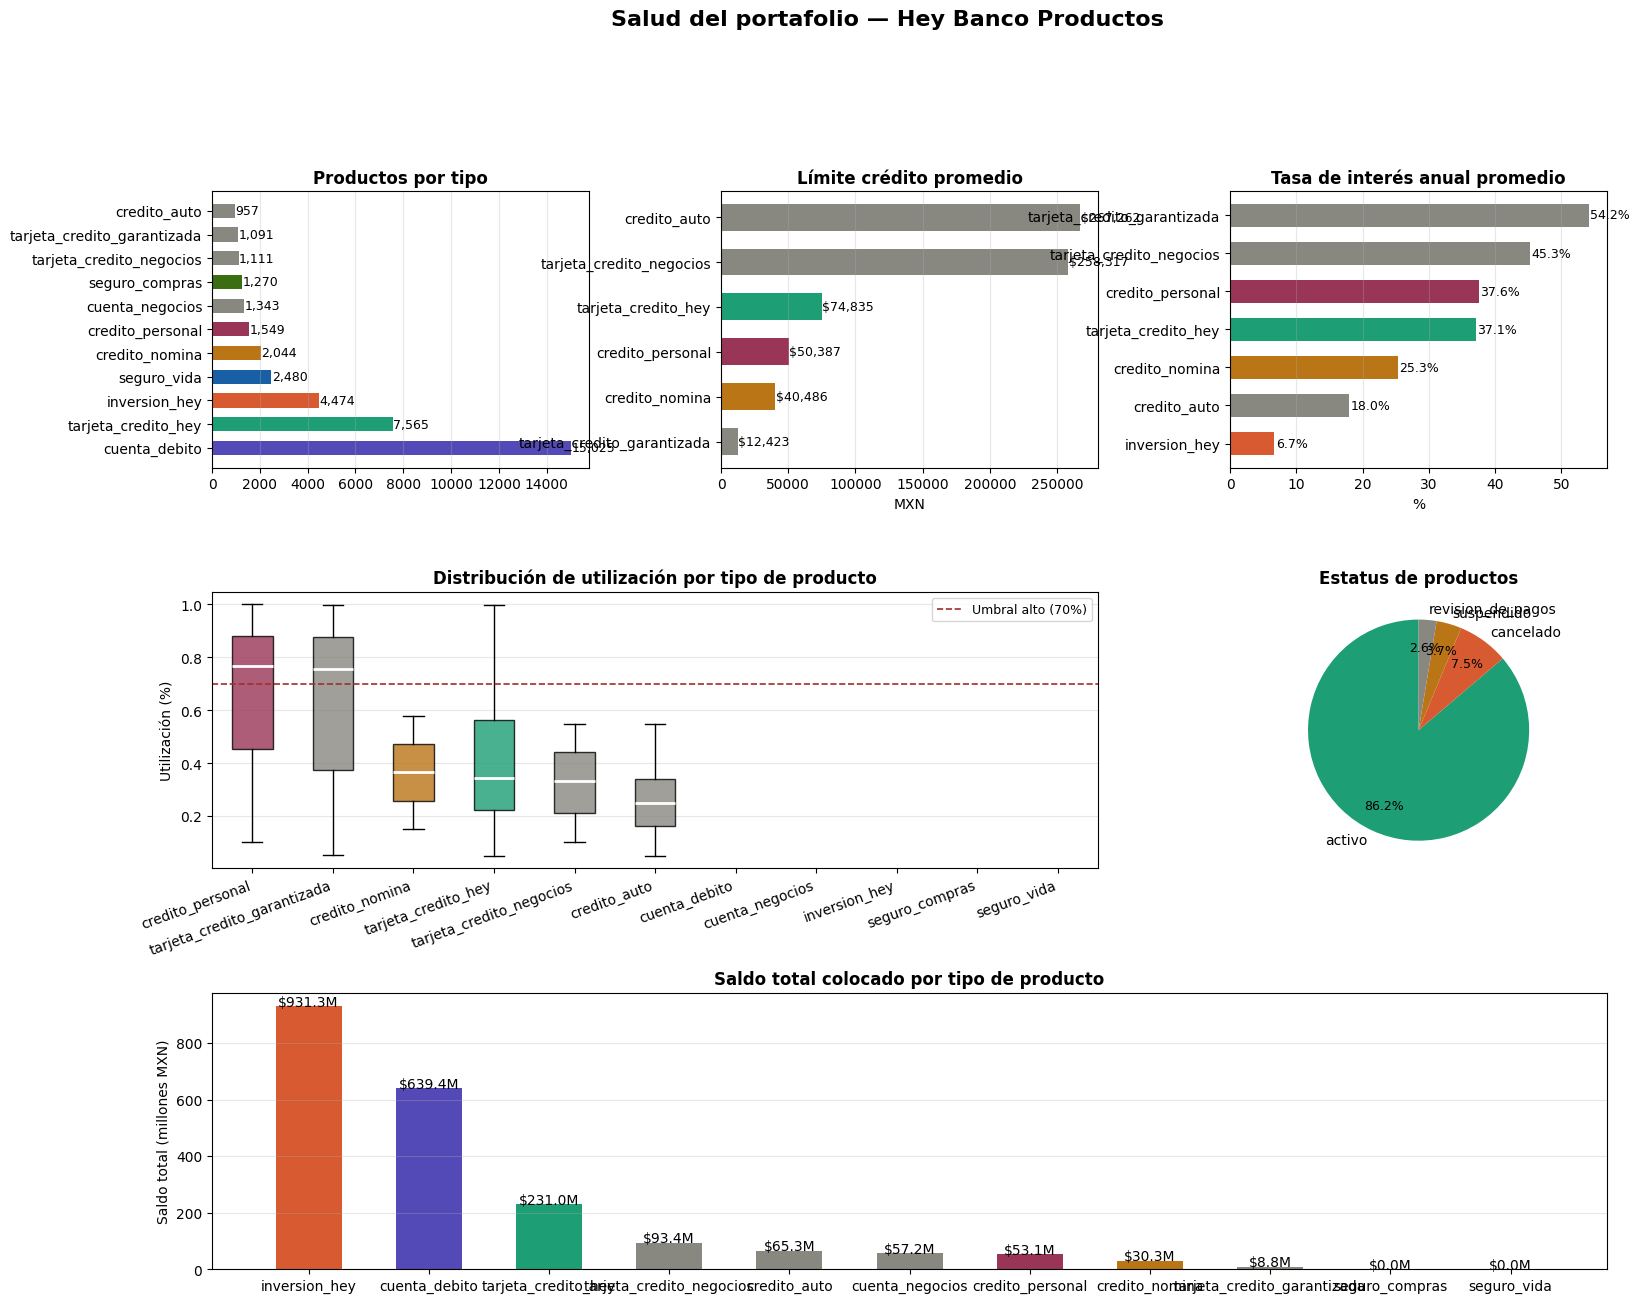

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec


# ── Parsear fechas ────────────────────────────────────────────────────────────
daf['fecha_apertura'] = pd.to_datetime(daf['fecha_apertura'], errors='coerce')
daf['fecha_ultimo_movimiento'] = pd.to_datetime(daf['fecha_ultimo_movimiento'], errors='coerce')
daf['antiguedad_producto_dias'] = (pd.Timestamp.today() - daf['fecha_apertura']).dt.days
daf['dias_sin_movimiento'] = (pd.Timestamp.today() - daf['fecha_ultimo_movimiento']).dt.days

# ── 1. Distribución y métricas por tipo de producto ──────────────────────────
fig = plt.figure(figsize=(18, 14))
gs  = GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])
ax4 = fig.add_subplot(gs[1, :2])
ax5 = fig.add_subplot(gs[1, 2])
ax6 = fig.add_subplot(gs[2, :])

colores_tipo = {t: c for t, c in zip(
    daf['tipo_producto'].unique(),
    ['#534AB7','#1D9E75','#D85A30','#BA7517','#185FA5','#993556','#3B6D11']
)}

# Gráfica 1: Conteo por tipo
conteo = daf['tipo_producto'].value_counts()
ax1.barh(conteo.index, conteo.values,
         color=[colores_tipo.get(t,'#888780') for t in conteo.index],
         edgecolor='none', height=0.6)
ax1.set_title('Productos por tipo', fontweight='bold')
ax1.grid(axis='x', alpha=0.3)
for i, (idx, val) in enumerate(conteo.items()):
    ax1.text(val+20, i, f'{val:,}', va='center', fontsize=9)

# Gráfica 2: Límite de crédito promedio por tipo
lim_prom = daf.groupby('tipo_producto')['limite_credito'].mean().sort_values()
ax2.barh(lim_prom.index, lim_prom.values,
         color=[colores_tipo.get(t,'#888780') for t in lim_prom.index],
         edgecolor='none', height=0.6)
ax2.set_title('Límite crédito promedio', fontweight='bold')
ax2.set_xlabel('MXN')
ax2.grid(axis='x', alpha=0.3)
for i, (idx, val) in enumerate(lim_prom.items()):
    ax2.text(val+500, i, f'${val:,.0f}', va='center', fontsize=9)

# Gráfica 3: Tasa de interés promedio por tipo
tasa_prom = daf.groupby('tipo_producto')['tasa_interes_anual'].mean().sort_values()
ax3.barh(tasa_prom.index, tasa_prom.values,
         color=[colores_tipo.get(t,'#888780') for t in tasa_prom.index],
         edgecolor='none', height=0.6)
ax3.set_title('Tasa de interés anual promedio', fontweight='bold')
ax3.set_xlabel('%')
ax3.grid(axis='x', alpha=0.3)
for i, (idx, val) in enumerate(tasa_prom.items()):
    ax3.text(val+0.2, i, f'{val:.1f}%', va='center', fontsize=9)

# Gráfica 4: Utilización promedio por tipo — boxplot
tipos_orden = daf.groupby('tipo_producto')['utilizacion_pct'].median().sort_values(ascending=False).index.tolist()
data_box = [daf[daf['tipo_producto']==t]['utilizacion_pct'].dropna().values for t in tipos_orden]
bp = ax4.boxplot(data_box, vert=True, patch_artist=True, widths=0.5,
                 medianprops=dict(color='white', linewidth=2))
for patch, tipo in zip(bp['boxes'], tipos_orden):
    patch.set_facecolor(colores_tipo.get(tipo, '#888780'))
    patch.set_alpha(0.8)
ax4.set_xticklabels(tipos_orden, rotation=20, ha='right')
ax4.set_ylabel('Utilización (%)')
ax4.set_title('Distribución de utilización por tipo de producto', fontweight='bold')
ax4.axhline(0.7, color='#A32D2D', linestyle='--', linewidth=1.2, label='Umbral alto (70%)')
ax4.legend(fontsize=9)
ax4.grid(axis='y', alpha=0.3)

# Gráfica 5: Estatus (activo/inactivo/etc)
estatus_conteo = daf['estatus'].value_counts()
wedges, texts, autotexts = ax5.pie(
    estatus_conteo.values,
    labels=estatus_conteo.index,
    autopct='%1.1f%%',
    colors=['#1D9E75','#D85A30','#BA7517','#888780'][:len(estatus_conteo)],
    startangle=90, pctdistance=0.75
)
for t in autotexts: t.set_fontsize(9)
ax5.set_title('Estatus de productos', fontweight='bold')

# Gráfica 6: Saldo total por tipo de producto (ingreso al banco)
saldo_total = daf.groupby('tipo_producto')['saldo_actual'].sum().sort_values(ascending=False)
bars = ax6.bar(saldo_total.index, saldo_total.values/1e6,
               color=[colores_tipo.get(t,'#888780') for t in saldo_total.index],
               edgecolor='none', width=0.55)
ax6.set_ylabel('Saldo total (millones MXN)')
ax6.set_title('Saldo total colocado por tipo de producto', fontweight='bold')
ax6.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, saldo_total.values/1e6):
    ax6.text(bar.get_x()+bar.get_width()/2, val+0.5,
             f'${val:.1f}M', ha='center', fontsize=10)

plt.suptitle('Salud del portafolio — Hey Banco Productos', fontsize=16, fontweight='bold', y=1.01)
plt.show()

#Uso crediticio

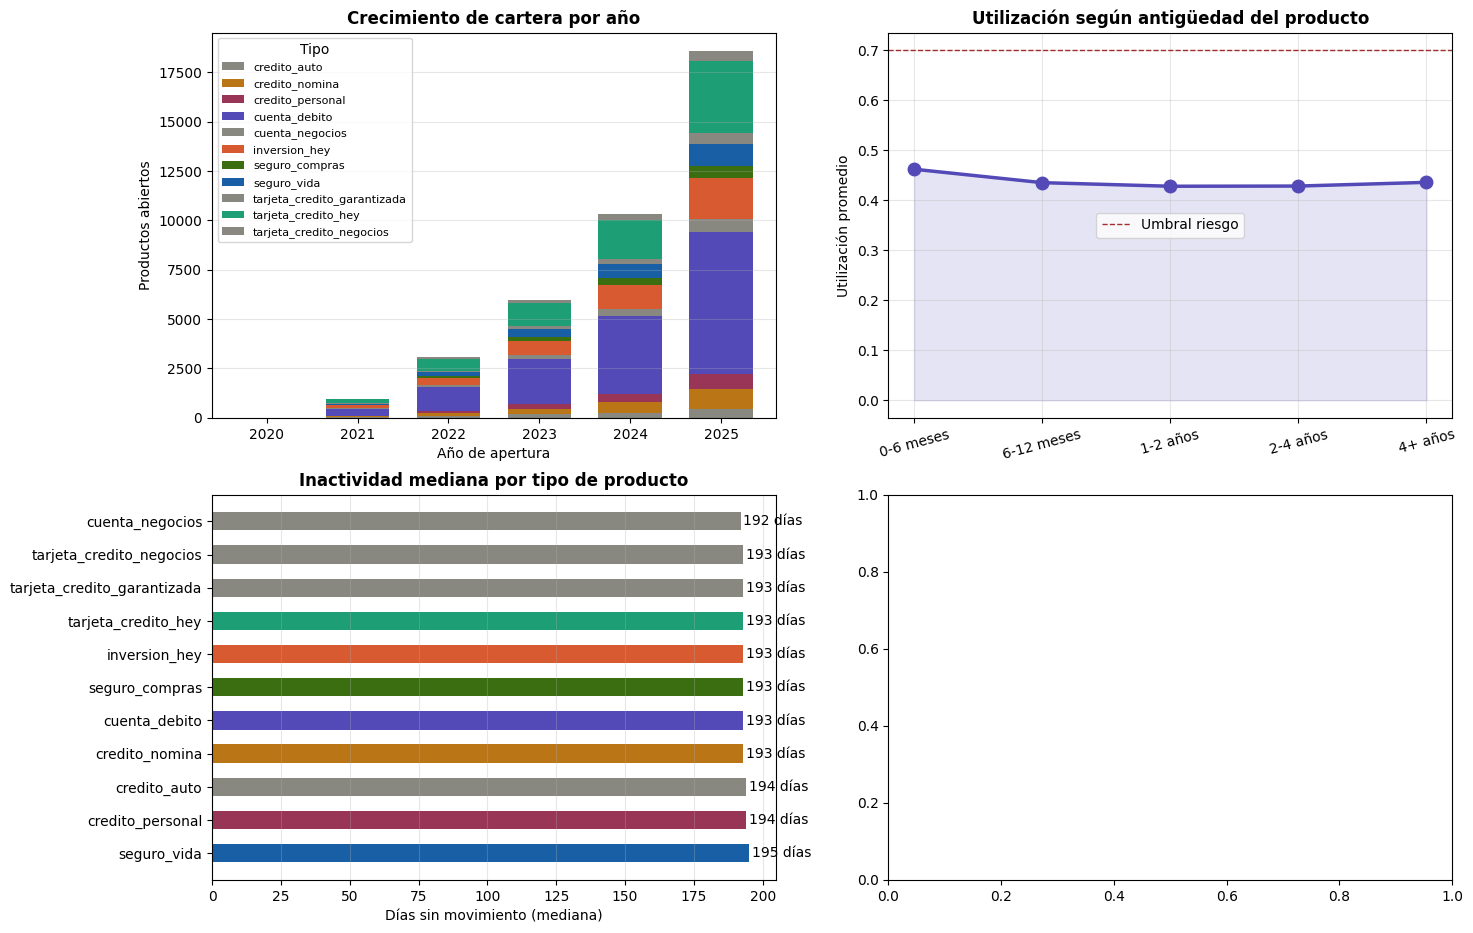

In [13]:
# ── Análisis de antigüedad y actividad ───────────────────────────────────────
daf['anio_apertura'] = daf['fecha_apertura'].dt.year
daf['mes_apertura']  = daf['fecha_apertura'].dt.to_period('M').astype(str)

# Categorías de madurez del producto
def madurez(dias):
    if   dias < 180:  return '0-6 meses'
    elif dias < 365:  return '6-12 meses'
    elif dias < 730:  return '1-2 años'
    elif dias < 1460: return '2-4 años'
    else:             return '4+ años'

daf['madurez'] = daf['antiguedad_producto_dias'].apply(madurez)

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# 1. Apertura de productos por año
apertura_anio = daf.groupby(['anio_apertura','tipo_producto']).size().unstack(fill_value=0)
apertura_anio.plot(kind='bar', ax=axes[0,0], stacked=True,
                   color=[colores_tipo.get(t,'#888780') for t in apertura_anio.columns],
                   edgecolor='none', width=0.7)
axes[0,0].set_xlabel('Año de apertura')
axes[0,0].set_ylabel('Productos abiertos')
axes[0,0].set_title('Crecimiento de cartera por año', fontweight='bold')
axes[0,0].legend(fontsize=8, title='Tipo')
axes[0,0].tick_params(axis='x', rotation=0)
axes[0,0].grid(axis='y', alpha=0.3)

# 2. Utilización según madurez del producto
orden_madurez = ['0-6 meses','6-12 meses','1-2 años','2-4 años','4+ años']
util_madurez = daf.groupby('madurez')['utilizacion_pct'].mean().reindex(
    [m for m in orden_madurez if m in daf['madurez'].values]
)
axes[0,1].plot(util_madurez.index, util_madurez.values,
               'o-', color='#534AB7', linewidth=2.5, markersize=9)
axes[0,1].fill_between(range(len(util_madurez)), util_madurez.values,
                        alpha=0.15, color='#534AB7')
axes[0,1].set_xticks(range(len(util_madurez)))
axes[0,1].set_xticklabels(util_madurez.index, rotation=15)
axes[0,1].set_ylabel('Utilización promedio')
axes[0,1].set_title('Utilización según antigüedad del producto', fontweight='bold')
axes[0,1].axhline(0.70, color='#A32D2D', linestyle='--', linewidth=1, label='Umbral riesgo')
axes[0,1].legend()
axes[0,1].grid(alpha=0.3)

# 3. Días sin movimiento por tipo (inactividad)
inact = daf.groupby('tipo_producto')['dias_sin_movimiento'].median().sort_values(ascending=False)
bars = axes[1,0].barh(inact.index, inact.values,
                       color=[colores_tipo.get(t,'#888780') for t in inact.index],
                       edgecolor='none', height=0.55)
axes[1,0].set_xlabel('Días sin movimiento (mediana)')
axes[1,0].set_title('Inactividad mediana por tipo de producto', fontweight='bold')
axes[1,0].grid(axis='x', alpha=0.3)
for bar, val in zip(bars, inact.values):
    axes[1,0].text(val+1, bar.get_y()+bar.get_height()/2,
                   f'{val:.0f} días', va='center', fontsize=10)


In [14]:
productos_limpios["producto_activo"] = (
    productos_limpios["estatus"] == "activo"
).astype(int)

productos_limpios["producto_cancelado"] = (
    productos_limpios["estatus"] == "cancelado"
).astype(int)

productos_limpios["producto_suspendido"] = (
    productos_limpios["estatus"] == "suspendido"
).astype(int)

productos_limpios["producto_en_revision"] = (
    productos_limpios["estatus"] == "revision_de_pagos"
).astype(int)

productos_limpios["es_credito"] = (
    productos_limpios["tipo_producto"].str.contains("credito", case=False, na=False)
).astype(int)

productos_limpios["es_tarjeta"] = (
    productos_limpios["tipo_producto"].str.contains("tarjeta", case=False, na=False)
).astype(int)

productos_limpios["es_seguro"] = (
    productos_limpios["tipo_producto"].str.contains("seguro", case=False, na=False)
).astype(int)

productos_limpios["es_cuenta"] = (
    productos_limpios["tipo_producto"].str.contains("cuenta", case=False, na=False)
).astype(int)

productos_limpios["es_inversion"] = (
    productos_limpios["tipo_producto"].str.contains("inversion", case=False, na=False)
).astype(int)

In [15]:
print("Filas:", productos_limpios.shape[0])
print("Columnas:", productos_limpios.shape[1])
print("Nulos totales:", productos_limpios.isnull().sum().sum())
print("Producto_id nulos:", productos_limpios["producto_id"].isnull().sum())
print("User_id nulos:", productos_limpios["user_id"].isnull().sum())
print("Producto_id duplicados:", productos_limpios["producto_id"].duplicated().sum())

Filas: 38909
Columnas: 28
Nulos totales: 0
Producto_id nulos: 0
User_id nulos: 0
Producto_id duplicados: 0


In [16]:
def moda_segura(serie):
    serie = serie.dropna()
    if serie.empty:
        return "sin_dato"
    return serie.mode().iloc[0]

productos_features = productos_limpios.groupby("user_id").agg(
    total_productos=("producto_id", "count"),
    productos_activos=("producto_activo", "sum"),
    productos_cancelados=("producto_cancelado", "sum"),
    productos_suspendidos=("producto_suspendido", "sum"),
    productos_en_revision=("producto_en_revision", "sum"),

    total_creditos=("es_credito", "sum"),
    total_tarjetas=("es_tarjeta", "sum"),
    total_seguros=("es_seguro", "sum"),
    total_cuentas=("es_cuenta", "sum"),
    total_inversiones=("es_inversion", "sum"),

    limite_credito_total=("limite_credito", "sum"),
    saldo_total_productos=("saldo_actual", "sum"),
    utilizacion_promedio=("utilizacion_pct", "mean"),
    tasa_interes_promedio=("tasa_interes_anual", "mean"),
    mensualidad_total=("monto_mensualidad", "sum"),

    producto_principal=("tipo_producto", moda_segura),
    estatus_principal=("estatus", moda_segura),
    fecha_producto_mas_reciente=("fecha_apertura", "max"),
    fecha_ultimo_movimiento_producto=("fecha_ultimo_movimiento", "max")
).reset_index()

productos_features.head()

,user_id,total_productos,productos_activos,productos_cancelados,productos_suspendidos,productos_en_revision,total_creditos,total_tarjetas,total_seguros,total_cuentas,total_inversiones,limite_credito_total,saldo_total_productos,utilizacion_promedio,tasa_interes_promedio,mensualidad_total,producto_principal,estatus_principal,fecha_producto_mas_reciente,fecha_ultimo_movimiento_producto
0,USR-00001,2,2,0,0,0,1,1,0,1,0,144000.0,169745.00,0.308300,17.855,0.0,cuenta_debito,activo,2023-06-26,2025-11-27
1,USR-00002,2,2,0,0,0,1,1,0,1,0,22000.0,26835.14,0.139150,17.040,0.0,cuenta_debito,activo,2025-07-18,2025-10-16
2,USR-00003,2,2,0,0,0,1,1,0,1,0,5000.0,5000.15,0.154550,19.940,0.0,cuenta_debito,activo,2024-04-24,2025-10-15
3,USR-00004,3,3,0,0,0,1,1,0,1,1,67000.0,357230.61,0.117933,15.630,0.0,cuenta_debito,activo,2024-06-19,2025-11-08
4,USR-00005,2,2,0,0,0,1,1,0,1,0,136000.0,129359.71,0.316300,15.475,0.0,cuenta_debito,activo,2025-04-02,2025-11-21


In [17]:
# Rellenar nulos numéricos con 0
cols_num = productos_features.select_dtypes(include=["number"]).columns
productos_features[cols_num] = productos_features[cols_num].fillna(0)

# Rellenar textos con sin_dato
cols_texto = productos_features.select_dtypes(include=["object"]).columns
productos_features[cols_texto] = productos_features[cols_texto].fillna("sin_dato")

print("Nulos finales:", productos_features.isnull().sum().sum())
print("Duplicados user_id:", productos_features["user_id"].duplicated().sum())
productos_features.head()

Nulos finales: 0
Duplicados user_id: 0


C:\Users\CommodorePlus\AppData\Local\Temp\ipykernel_21024\1220362900.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cols_texto = productos_features.select_dtypes(include=["object"]).columns


,user_id,total_productos,productos_activos,productos_cancelados,productos_suspendidos,productos_en_revision,total_creditos,total_tarjetas,total_seguros,total_cuentas,total_inversiones,limite_credito_total,saldo_total_productos,utilizacion_promedio,tasa_interes_promedio,mensualidad_total,producto_principal,estatus_principal,fecha_producto_mas_reciente,fecha_ultimo_movimiento_producto
0,USR-00001,2,2,0,0,0,1,1,0,1,0,144000.0,169745.00,0.308300,17.855,0.0,cuenta_debito,activo,2023-06-26,2025-11-27
1,USR-00002,2,2,0,0,0,1,1,0,1,0,22000.0,26835.14,0.139150,17.040,0.0,cuenta_debito,activo,2025-07-18,2025-10-16
2,USR-00003,2,2,0,0,0,1,1,0,1,0,5000.0,5000.15,0.154550,19.940,0.0,cuenta_debito,activo,2024-04-24,2025-10-15
3,USR-00004,3,3,0,0,0,1,1,0,1,1,67000.0,357230.61,0.117933,15.630,0.0,cuenta_debito,activo,2024-06-19,2025-11-08
4,USR-00005,2,2,0,0,0,1,1,0,1,0,136000.0,129359.71,0.316300,15.475,0.0,cuenta_debito,activo,2025-04-02,2025-11-21


In [18]:
# Rellenar nulos numéricos con 0
cols_num = productos_features.select_dtypes(include=["number"]).columns
productos_features[cols_num] = productos_features[cols_num].fillna(0)

# Rellenar textos con sin_dato
cols_texto = productos_features.select_dtypes(include=["object"]).columns
productos_features[cols_texto] = productos_features[cols_texto].fillna("sin_dato")

print("Nulos finales:", productos_features.isnull().sum().sum())
print("Duplicados user_id:", productos_features["user_id"].duplicated().sum())
productos_features.head()

Nulos finales: 0
Duplicados user_id: 0


C:\Users\CommodorePlus\AppData\Local\Temp\ipykernel_21024\1220362900.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cols_texto = productos_features.select_dtypes(include=["object"]).columns


,user_id,total_productos,productos_activos,productos_cancelados,productos_suspendidos,productos_en_revision,total_creditos,total_tarjetas,total_seguros,total_cuentas,total_inversiones,limite_credito_total,saldo_total_productos,utilizacion_promedio,tasa_interes_promedio,mensualidad_total,producto_principal,estatus_principal,fecha_producto_mas_reciente,fecha_ultimo_movimiento_producto
0,USR-00001,2,2,0,0,0,1,1,0,1,0,144000.0,169745.00,0.308300,17.855,0.0,cuenta_debito,activo,2023-06-26,2025-11-27
1,USR-00002,2,2,0,0,0,1,1,0,1,0,22000.0,26835.14,0.139150,17.040,0.0,cuenta_debito,activo,2025-07-18,2025-10-16
2,USR-00003,2,2,0,0,0,1,1,0,1,0,5000.0,5000.15,0.154550,19.940,0.0,cuenta_debito,activo,2024-04-24,2025-10-15
3,USR-00004,3,3,0,0,0,1,1,0,1,1,67000.0,357230.61,0.117933,15.630,0.0,cuenta_debito,activo,2024-06-19,2025-11-08
4,USR-00005,2,2,0,0,0,1,1,0,1,0,136000.0,129359.71,0.316300,15.475,0.0,cuenta_debito,activo,2025-04-02,2025-11-21


In [ ]:

ruta_salida = "../data/clean/features/hey_productos_features_limpio.csv"

productos_features.to_csv(ruta_salida, index=False, encoding="utf-8-sig")

print(f"✅ Proceso completado. Archivo guardado en: {ruta_salida}")

✅ Proceso completado. Archivo guardado en: ../data/clean/features/hey_productos_features_limpio.csv
